## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [6]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [7]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [8]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [9]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [10]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [11]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [12]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [13]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [14]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [15]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [16]:
inks_df = inks_df.reset_index(drop=False)

In [17]:
inds_df = inds_df.reset_index(drop=False)

In [18]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [19]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [20]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [21]:
inDKs_df.dropna(inplace=True)

In [22]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [23]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [24]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

### Creating features and labels matrices

In [25]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [26]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

### Normalization

In [27]:
X = (X - np.mean(X, axis=0))/np.std(X, axis=0)
y = (y - np.mean(y, axis=0))/np.std(y, axis=0)

### Converting to tensors

In [28]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [29]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [30]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [31]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [32]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [33]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [34]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [35]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [36]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [37]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [39]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [53]:
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [54]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [55]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.11842340330282847 test 0.12964583664368953
EPOCH 2:
LOSS train 0.11559364000956217 test 0.12970701787682484
EPOCH 3:
LOSS train 0.1172527939081192 test 0.1296885891240977
EPOCH 4:
LOSS train 0.11952945441007615 test 0.1296779909200087
EPOCH 5:
LOSS train 0.11752169678608576 test 0.12966880639417264
EPOCH 6:
LOSS train 0.11710859636465708 test 0.12965417656792988
EPOCH 7:
LOSS train 0.11700970083475112 test 0.1296801906229454
EPOCH 8:
LOSS train 0.1161972314119339 test 0.12967176156939927
EPOCH 9:
LOSS train 0.1163193811972936 test 0.12969300427182923
EPOCH 10:
LOSS train 0.1158836675186952 test 0.1296594068620115
EPOCH 11:
LOSS train 0.11593908419211706 test 0.12967887616621843
EPOCH 12:
LOSS train 0.11678117712338766 test 0.12968855150676414
EPOCH 13:
LOSS train 0.11800734549760819 test 0.12964829659054738
EPOCH 14:
LOSS train 0.11844503631194432 test 0.12968725289023378
EPOCH 15:
LOSS train 0.11610130816698075 test 0.12967474681689686
EPOCH 16:
LOSS train 0.1199

LOSS train 0.11673034777243932 test 0.1295394544483897
EPOCH 128:
LOSS train 0.1169688935081164 test 0.12958028958435508
EPOCH 129:
LOSS train 0.11756064246098201 test 0.1295591889327203
EPOCH 130:
LOSS train 0.12012626826763154 test 0.1295586425317432
EPOCH 131:
LOSS train 0.11994532768925031 test 0.12959228987626223
EPOCH 132:
LOSS train 0.11701903243859609 test 0.1295921282715494
EPOCH 133:
LOSS train 0.11671711703141531 test 0.12955725067304774
EPOCH 134:
LOSS train 0.11796205341815949 test 0.12957953989474916
EPOCH 135:
LOSS train 0.11815293729305268 test 0.1295410196545609
EPOCH 136:
LOSS train 0.11665133982896805 test 0.12957330306270787
EPOCH 137:
LOSS train 0.11976374909281731 test 0.1295557674174785
EPOCH 138:
LOSS train 0.1172658105691274 test 0.12953142943458465
EPOCH 139:
LOSS train 0.11687895754973093 test 0.1295365934736456
EPOCH 140:
LOSS train 0.11620793292919794 test 0.12955476423266574
EPOCH 141:
LOSS train 0.11703480929136276 test 0.12955841725965958
EPOCH 142:
LOSS

LOSS train 0.11656555434068044 test 0.1294170103072503
EPOCH 252:
LOSS train 0.12031676570574443 test 0.12938701152014806
EPOCH 253:
LOSS train 0.11804595092932384 test 0.12941824897205917
EPOCH 254:
LOSS train 0.11871101607879003 test 0.12941143700879984
EPOCH 255:
LOSS train 0.11690293500820796 test 0.1293766560056102
EPOCH 256:
LOSS train 0.11844453811645508 test 0.12941633227549293
EPOCH 257:
LOSS train 0.11679435322682062 test 0.12936836224836037
EPOCH 258:
LOSS train 0.11704027404387791 test 0.12941418396883622
EPOCH 259:
LOSS train 0.11684883236885071 test 0.12936828792380559
EPOCH 260:
LOSS train 0.11951762040456136 test 0.12938578012659682
EPOCH 261:
LOSS train 0.11582551250855128 test 0.12939420831630752
EPOCH 262:
LOSS train 0.11647806862990061 test 0.12936568673985469
EPOCH 263:
LOSS train 0.11789148350556691 test 0.12936605485136896
EPOCH 264:
LOSS train 0.11574250434835752 test 0.1293850014792219
EPOCH 265:
LOSS train 0.11676436314980189 test 0.12935623403553762
EPOCH 266

LOSS train 0.1159979060292244 test 0.12932138576502014
EPOCH 376:
LOSS train 0.11667992472648621 test 0.12927787228608908
EPOCH 377:
LOSS train 0.11684779028097789 test 0.12930415236770984
EPOCH 378:
LOSS train 0.11648479203383127 test 0.12933120057642397
EPOCH 379:
LOSS train 0.1203410118818283 test 0.12934780296701823
EPOCH 380:
LOSS train 0.11723515888055165 test 0.1293395784631464
EPOCH 381:
LOSS train 0.11818282157182694 test 0.1293328080064083
EPOCH 382:
LOSS train 0.12024929622809093 test 0.12931727190110562
EPOCH 383:
LOSS train 0.11682397574186325 test 0.12931793702739305
EPOCH 384:
LOSS train 0.11650436272223791 test 0.12930018449969605
EPOCH 385:
LOSS train 0.11855192383130392 test 0.1293222508325741
EPOCH 386:
LOSS train 0.11528623749812444 test 0.12930945040345748
EPOCH 387:
LOSS train 0.11548315435647964 test 0.12931352734804832
EPOCH 388:
LOSS train 0.11877629508574804 test 0.1293376683841766
EPOCH 389:
LOSS train 0.11922633697589238 test 0.12932818201148794
EPOCH 390:
L

LOSS train 0.11636664519707361 test 0.12925801285606178
EPOCH 500:
LOSS train 0.11744893540938696 test 0.12925435520909095
EPOCH 501:
LOSS train 0.1164649615685145 test 0.12922607063784364
EPOCH 502:
LOSS train 0.11668615092833837 test 0.12925842464911147
EPOCH 503:
LOSS train 0.11623396923144659 test 0.12925422160768607
EPOCH 504:
LOSS train 0.11929857283830643 test 0.12926107108029952
EPOCH 505:
LOSS train 0.11673272699117661 test 0.12924070049879405
EPOCH 506:
LOSS train 0.12109926193952561 test 0.12925482321507442
EPOCH 507:
LOSS train 0.11807025422652563 test 0.12924231977566428
EPOCH 508:
LOSS train 0.11752827515204747 test 0.1292497028170566
EPOCH 509:
LOSS train 0.11554468721151352 test 0.12924110416253531
EPOCH 510:
LOSS train 0.1178557887673378 test 0.12922042407920703
EPOCH 511:
LOSS train 0.11634146521488825 test 0.12924341128186534
EPOCH 512:
LOSS train 0.11681153923273087 test 0.12925326604180146
EPOCH 513:
LOSS train 0.11573550701141358 test 0.12929032660450007
EPOCH 514

LOSS train 0.11886727561553319 test 0.12925745112779038
EPOCH 624:
LOSS train 0.11798625340064367 test 0.1292609634961524
EPOCH 625:
LOSS train 0.1165725514292717 test 0.12918031093998047
EPOCH 626:
LOSS train 0.11628281076749165 test 0.12921816925277188
EPOCH 627:
LOSS train 0.11572179694970448 test 0.12920956210836798
EPOCH 628:
LOSS train 0.11765782237052917 test 0.12922776291266422
EPOCH 629:
LOSS train 0.11795469423135121 test 0.1291974070954366
EPOCH 630:
LOSS train 0.11550668229659398 test 0.12920162368635213
EPOCH 631:
LOSS train 0.12064912617206573 test 0.1292134104315847
EPOCH 632:
LOSS train 0.11860112200180689 test 0.12920044798511957
EPOCH 633:
LOSS train 0.11546389212210974 test 0.12918255087489544
EPOCH 634:
LOSS train 0.11581662793954213 test 0.12921462182387494
EPOCH 635:
LOSS train 0.11657584309577942 test 0.12919691438144593
EPOCH 636:
LOSS train 0.1161609893043836 test 0.12922113598372564
EPOCH 637:
LOSS train 0.11984339704116186 test 0.12919357609906182
EPOCH 638:


LOSS train 0.11853161801894506 test 0.1291825403391883
EPOCH 748:
LOSS train 0.1158787469069163 test 0.129123085539009
EPOCH 749:
LOSS train 0.11657746036847433 test 0.12917503398335992
EPOCH 750:
LOSS train 0.11823862592379251 test 0.1291689033163075
EPOCH 751:
LOSS train 0.11708162029584249 test 0.12917698259748842
EPOCH 752:
LOSS train 0.12057267278432846 test 0.12922306300968117
EPOCH 753:
LOSS train 0.11774241924285889 test 0.12917050060972293
EPOCH 754:
LOSS train 0.11723389228185017 test 0.12919404492838843
EPOCH 755:
LOSS train 0.11565269927183787 test 0.12919681012345088
EPOCH 756:
LOSS train 0.11804308146238326 test 0.12916014227807893
EPOCH 757:
LOSS train 0.11815621455510457 test 0.1291626233272023
EPOCH 758:
LOSS train 0.11680091818173727 test 0.12917387284392465
EPOCH 759:
LOSS train 0.11639939993619919 test 0.12917615388429438
EPOCH 760:
LOSS train 0.11685329626003901 test 0.1291852500983832
EPOCH 761:
LOSS train 0.11594587514797847 test 0.12920364516924132
EPOCH 762:
LO

LOSS train 0.11579638123512268 test 0.129169981826413
EPOCH 872:
LOSS train 0.11828450784087181 test 0.12915909140299442
EPOCH 873:
LOSS train 0.11607086857159933 test 0.12917054095932168
EPOCH 874:
LOSS train 0.11670808841784795 test 0.12920710257028942
EPOCH 875:
LOSS train 0.11977912435928981 test 0.129183690079081
EPOCH 876:
LOSS train 0.11590277155240376 test 0.12921315652567036
EPOCH 877:
LOSS train 0.1163624996940295 test 0.12918461198816328
EPOCH 878:
LOSS train 0.11796844899654388 test 0.12917675579248256
EPOCH 879:
LOSS train 0.1164677898089091 test 0.12915961925272
EPOCH 880:
LOSS train 0.11655268321434657 test 0.12916074467795916
EPOCH 881:
LOSS train 0.11726449579000472 test 0.12921174076495703
EPOCH 882:
LOSS train 0.11590116719404857 test 0.12914323079829754
EPOCH 883:
LOSS train 0.12256528983513514 test 0.12926776622717054
EPOCH 884:
LOSS train 0.11655257741610209 test 0.12920697235673914
EPOCH 885:
LOSS train 0.11751767645279566 test 0.12920125523161752
EPOCH 886:
LOSS

LOSS train 0.11602944731712342 test 0.12916707274683328
EPOCH 996:
LOSS train 0.11716732929150263 test 0.12913809413202185
EPOCH 997:
LOSS train 0.11759274303913117 test 0.1291788666225646
EPOCH 998:
LOSS train 0.12106340179840723 test 0.1291558626715256
EPOCH 999:
LOSS train 0.11729697609941164 test 0.12911949993552752
EPOCH 1000:
LOSS train 0.11980796655019124 test 0.12914511560622458
EPOCH 1001:
LOSS train 0.1174784317612648 test 0.129187601356233
EPOCH 1002:
LOSS train 0.11673645973205567 test 0.12917533773142173
EPOCH 1003:
LOSS train 0.11603904714186987 test 0.1291536870730682
EPOCH 1004:
LOSS train 0.11622978250185649 test 0.12925175061607522
EPOCH 1005:
LOSS train 0.11566482037305832 test 0.12921411618513226
EPOCH 1006:
LOSS train 0.11620094080766043 test 0.12928853598162995
EPOCH 1007:
LOSS train 0.1165799081325531 test 0.12917117529026162
EPOCH 1008:
LOSS train 0.1164782240986824 test 0.12920314631006424
EPOCH 1009:
LOSS train 0.1150938851137956 test 0.12918705880780768
EPOCH

KeyboardInterrupt: 

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

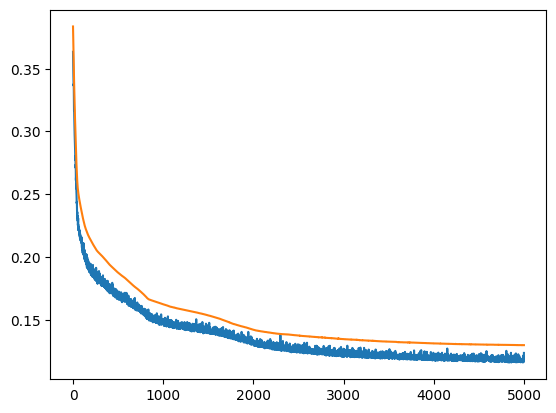

In [43]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

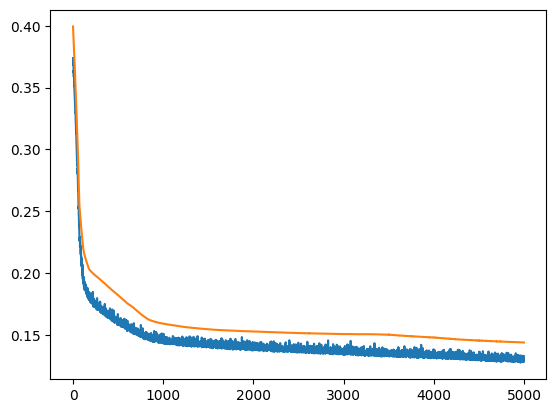

In [41]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

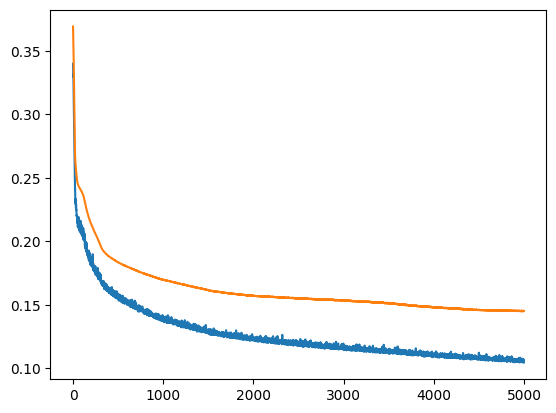

In [41]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

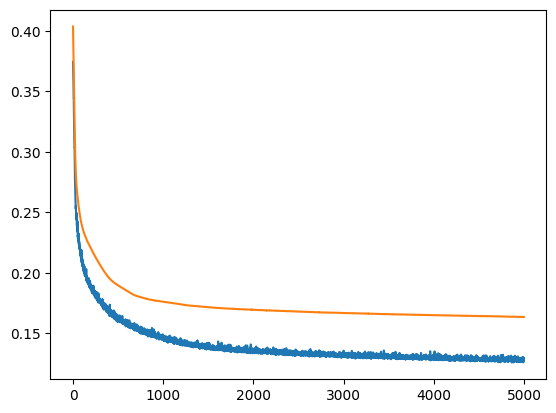

In [38]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

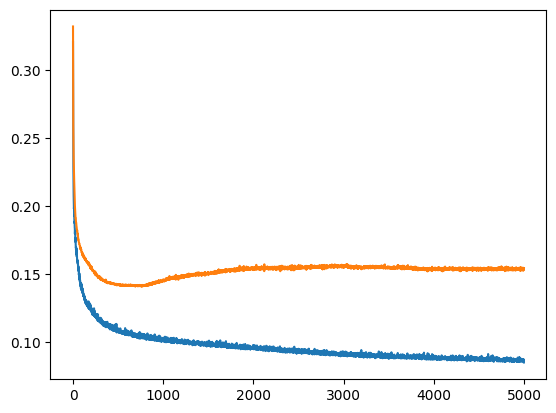

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

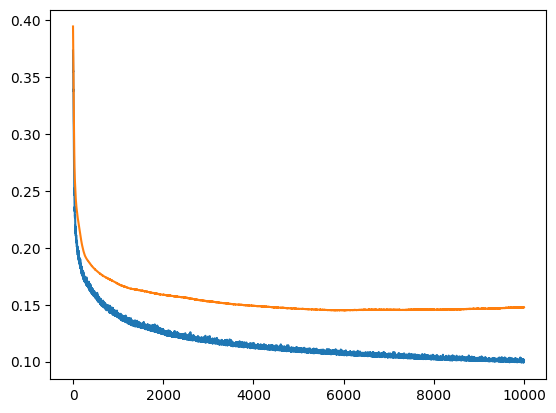

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [42]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    res = torch.concat((res, abs(outputs-labels)), axis=0)
    lab = torch.concat((lab, labels), axis=0)
    out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [47]:
lab

tensor([[-0.2766,  2.2387,  0.6446,  ..., -0.0732, -0.1286, -0.0917],
        [-0.2766,  2.2387,  0.6446,  ..., -0.0732, -0.1286, -0.0917],
        [-0.1264,  0.0796, -0.1687,  ..., -0.0725, -0.0783, -0.0770],
        ...,
        [-0.1534, -0.1260, -0.1700,  ..., -0.0736, -0.1950, -0.0927],
        [-0.2794, -0.1251, -0.1701,  ..., -0.0647,  1.2644,  0.1843],
        [-0.2665, -0.1575, -0.1701,  ..., -0.0738, -0.2081, -0.0966]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [49]:
out

tensor([[-0.2012,  1.0621, -0.0849,  ...,  0.0287,  1.6572, -0.0805],
        [-0.2012,  1.0621, -0.0849,  ...,  0.0287,  1.6572, -0.0805],
        [-0.1925, -0.1284, -0.1667,  ..., -0.0753, -0.1848, -0.0796],
        ...,
        [-0.1219, -0.1151, -0.1577,  ..., -0.0803, -0.0916, -0.0728],
        [-0.2568, -0.1474, -0.1687,  ..., -0.0743, -0.1724, -0.0922],
        [-0.2488, -0.1438, -0.1692,  ..., -0.0736, -0.1720, -0.0923]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [53]:
res

tensor([[7.5492e-02, 1.1766e+00, 7.2943e-01,  ..., 1.0198e-01, 1.7858e+00,
         1.1211e-02],
        [7.5492e-02, 1.1766e+00, 7.2943e-01,  ..., 1.0198e-01, 1.7858e+00,
         1.1211e-02],
        [6.6105e-02, 2.0794e-01, 2.0811e-03,  ..., 2.8437e-03, 1.0652e-01,
         2.6176e-03],
        ...,
        [3.1484e-02, 1.0902e-02, 1.2325e-02,  ..., 6.6911e-03, 1.0341e-01,
         1.9886e-02],
        [2.2569e-02, 2.2297e-02, 1.3337e-03,  ..., 9.6019e-03, 1.4368e+00,
         2.7656e-01],
        [1.7671e-02, 1.3685e-02, 8.6679e-04,  ..., 2.2545e-04, 3.6056e-02,
         4.3181e-03]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [54]:
torch.mean(res, axis=0)

tensor([0.1740, 0.1019, 0.1329, 0.3091, 0.1423, 0.0467, 0.1324, 0.0432],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [56]:
torch.mean(res)

tensor(0.1353, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [60]:
dim_nr = 0
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [61]:
#torch.max(out, axis=0)

(0.0, 4.0)

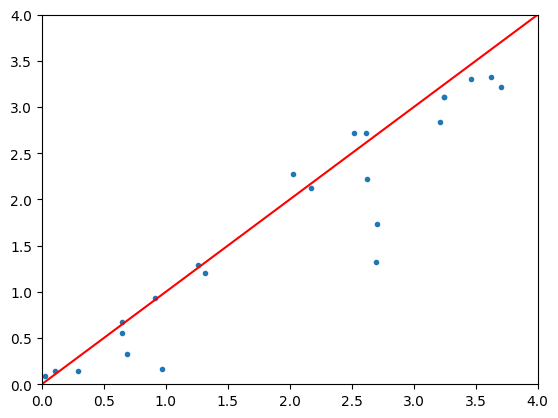

In [62]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(0, 4)
plt.ylim(0, 4)

In [63]:
torch.mean(res, 0)

tensor([0.1740, 0.1019, 0.1329, 0.3091, 0.1423, 0.0467, 0.1324, 0.0432],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [64]:
mean_loss

0.13389697226871183

## Interpretability

...